# 01 · Данные и локальная валидация

**Задача:** вернуть до 50 уникальных объявлений на запрос

Исходные файлы должны лежать в `data/`.

In [1]:
from pathlib import Path
import hashlib
import platform
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import display
from matplotlib.ticker import PercentFormatter

%matplotlib inline
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/train.parquet').exists())
DATA = ROOT / 'data'
START = time.perf_counter()
pd.set_option('display.max_colwidth', 85)
plt.rcParams.update({'figure.figsize': (9, 3.5), 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.2})
COLORS = ['#386CB0', '#E58F34']
print(f'Python {platform.python_version()} · pandas {pd.__version__} · PyArrow {pa.__version__}')

Python 3.12.3 · pandas 3.0.6 · PyArrow 25.0.1


## 1. Файлы, схемы и пропуски

`train` содержит положительные пары «поиск - объявление». `benchmark_queries` - запросы
для финального ответа, `benchmark_items` - каталог финального поиска. Benchmark-разметка не предоставлена.
Далее проверка размеров, типов, пустых значений и числа уникальных значений ключевых полей.

In [2]:
def profile_file(path):
    parquet = pq.ParquetFile(path)
    fields = parquet.schema_arrow.names
    nulls, empty = dict.fromkeys(fields, 0), dict.fromkeys(fields, 0)
    unique = {c: set() for c in fields if c.endswith('_id') or c.startswith('search_')
              and c not in ['search_infm_params_text'] or '_is_' in c}
    lengths = {c: [] for c in fields if c.endswith(('_text', '_raw')) or c == 'search_query'}
    examples = None
    for batch in parquet.iter_batches(batch_size=8192):
        if examples is None:
            examples = batch.slice(0, 3).to_pandas()
        for c in fields:
            a = batch.column(c)
            nulls[c] += a.null_count
            if pa.types.is_string(a.type) or pa.types.is_large_string(a.type):
                empty[c] += pc.sum(pc.cast(pc.equal(a, ''), pa.int64())).as_py() or 0
            if c in unique:
                unique[c].update(v for v in pc.unique(a).to_pylist() if v is not None)
            if c in lengths:
                lengths[c].append(pc.fill_null(pc.utf8_length(a), 0).to_numpy())
    return dict(rows=parquet.metadata.num_rows, columns=len(fields),
                schema={f.name: str(f.type) for f in parquet.schema_arrow}, nulls=nulls, empty=empty,
                unique={c: len(v) for c, v in unique.items()}, examples=examples,
                lengths={c: np.concatenate(v) for c, v in lengths.items()})

profiles = {name: profile_file(DATA / f'{name}.parquet')
            for name in ['train', 'benchmark_queries', 'benchmark_items']}
display(pd.DataFrame({name: {k: p[k] for k in ['rows', 'columns']}
                      for name, p in profiles.items()}).T.round(2))
display(pd.DataFrame({name: p['schema'] for name, p in profiles.items()}).fillna('—'))

,rows,columns
train,497673,19
benchmark_queries,2452,6
benchmark_items,189212,14


,train,benchmark_queries,benchmark_items
search_query,string,large_string,—
search_location_id,int64,int64,—
search_is_delivery_search,int32,int32,—
search_infm_params_text,string,large_string,—
search_category,int64,int64,—
item_title_raw,string,—,string
item_rating_reviews_count,double,—,double
item_rating,double,—,double
item_price,"decimal128(27, 15)",—,"decimal128(27, 15)"
item_microcat_id,int64,—,int64


In [3]:
missing = pd.DataFrame([
    {'набор': name, 'поле': c, 'NULL': p['nulls'][c], 'пустых строк': p['empty'][c],
     'доля NULL или пустых, %': 100 * (p['nulls'][c] + p['empty'][c]) / p['rows']}
    for name, p in profiles.items() for c in p['schema'] if p['nulls'][c] or p['empty'][c]
])
display(missing.round(2))
display(pd.DataFrame({name: p['unique'] for name, p in profiles.items()}).astype('Int64'))
display(profiles['train']['examples'][['search_query', 'search_infm_params_text', 'item_title_raw', 'item_id']])
display(profiles['benchmark_queries']['examples'][['query_id', 'search_query', 'search_category']])
display(profiles['benchmark_items']['examples'][['item_id', 'item_title_raw', 'item_category_id']])

,набор,поле,NULL,пустых строк,"доля NULL или пустых, %"
0,train,search_infm_params_text,0,163999,32.95
1,train,item_rating_reviews_count,19211,0,3.86
2,train,item_rating,28232,0,5.67
3,train,item_longitude,4,0,0.00
4,train,item_latitude,4,0,0.00
5,benchmark_queries,search_infm_params_text,0,1546,63.05
6,benchmark_items,item_rating_reviews_count,11615,0,6.14
7,benchmark_items,item_rating,17631,0,9.32
8,benchmark_items,item_longitude,1,0,0.00
9,benchmark_items,item_latitude,1,0,0.00


,train,benchmark_queries,benchmark_items
search_query,74529,2452,<NA>
search_location_id,2782,273,<NA>
search_is_delivery_search,2,1,<NA>
search_category,4,2,<NA>
item_microcat_id,212,<NA>,752
item_location_id,2637,<NA>,2877
item_is_phone_hidden,2,<NA>,2
item_is_message_forbidden,2,<NA>,2
item_id,344825,<NA>,189212
item_category_id,8,<NA>,47


,search_query,search_infm_params_text,item_title_raw,item_id
0,скупка телевизоров,,Скупка б/у техники,e8b685dffe1a408e
1,автоподбор,Рейтинг пользователя 4 звезды и выше,Автоподбор Разовый осмотр автомобиля,92e1b0446f827b59
2,баня на дровах,"Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье","Баня на дровах ""Прованс"" на Цветочной",624846856ce81d69


,query_id,search_query,search_category
0,70DfDUpwjxB4lzFd,перевозки владикавказ тбилиси,114
1,JTrdTaZJvSiLPkXj,обзвон по базе,114
2,LZCZNoVG4AFUkVRJ,липоредукция подбородка,114


,item_id,item_title_raw,item_category_id
0,111eb8b979577d79,Ремонт/выкуп компьют. и ноутбуков с выездом на дом,114
1,75fc8e10f5a66fc4,Обучение ребенка чтению,114
2,3f6ae81704565b9c,Афрокудри 5+,114


**Вывод**
В `train` нет пропусков в запросах, заголовках, описаниях и текстовых параметрах. В `benchmark` отсутствуют 35 описаний - нужно заменить пустой строкой. У рейтинга и количества отзывов есть пропуски. Отсутствующий рейтинг и рейтинг `0` - разные значения

## 2. Контексты и положительные пары

**Контекст** = текст + категория + локация + delivery-флаг + текст параметров поиска.
Одинаковые слова в разных городах -> разные контексты. 
Нормализацией приводим к нижнему регистру, убираем пунктуацию, `ё/е` и лишние пробелы, сохраняя цифры.

**Positive** - объявление, для которого в train известно положительное взаимодействие с этим контекстом. 

In [4]:
CONTEXT = ['search_query', 'search_category', 'search_location_id',
           'search_is_delivery_search', 'search_infm_params_text']
ITEM = ['item_id', 'item_category_id', 'item_microcat_id', 'item_location_id',
        'item_price', 'item_rating', 'item_rating_reviews_count',
        'item_is_phone_hidden', 'item_is_message_forbidden']

def read_columns(name, columns):
    frame = pd.read_parquet(DATA / f'{name}.parquet', columns=columns, dtype_backend='pyarrow')
    for c in columns:
        if c.endswith('_id') or c == 'search_category':
            frame[c] = frame[c].astype('string')
    return frame

def normalize(text):
    text = '' if pd.isna(text) else str(text).lower().replace('ё', 'е')
    return ' '.join(re.sub(r'[^\w\s]|_', ' ', text).split())

def normalize_context(frame):
    result = frame[CONTEXT].copy()
    for c in ['search_query', 'search_infm_params_text']:
        result[c] = result[c].map(normalize).astype('string')
    return result

train = read_columns('train', CONTEXT + ITEM)
queries = read_columns('benchmark_queries', ['query_id'] + CONTEXT)
items = read_columns('benchmark_items', ITEM)
tc, qc = normalize_context(train), normalize_context(queries)
train['context_code'] = pd.factorize(pd.MultiIndex.from_frame(tc), sort=False)[0]
pairs = train.drop_duplicates(['context_code', 'item_id'])
positives = pairs.groupby('context_code').size()
train_items = train.drop_duplicates('item_id')
train_ids, benchmark_ids = set(train.item_id), set(items.item_id)

,Количество
Исходные тексты запросов,74529
Нормализованные тексты,73706
Исходные контексты,354463
Нормализованные контексты,354241
Уникальные объявления,344825
Повторные пары после нормализации,30654
Контексты с одним positive,300987
Контексты с >50 positives,42


,Positives на контекст
count,354241.000
mean,1.318
std,1.612
min,1.000
50%,1.000
90%,2.000
95%,3.000
99%,6.000
max,278.000


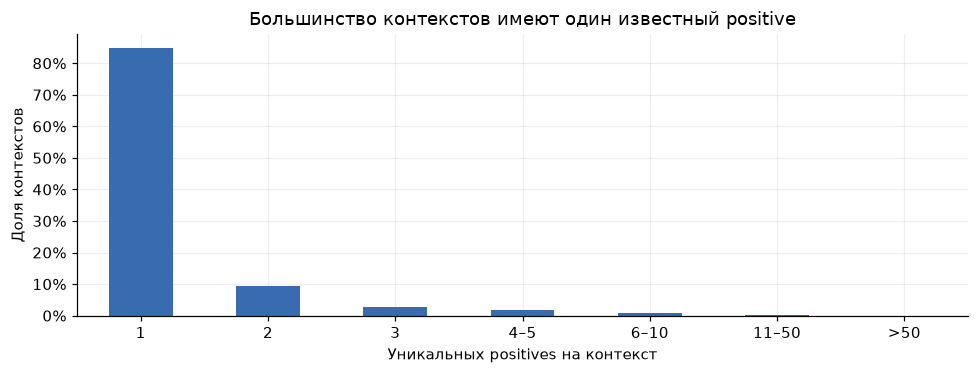

,search_query,search_location_id,search_infm_params_text,positives
context_code,,,,
1847,маникюр,637640,тип услуги маникюр педикюр вид услуги красота здоровье,278
3044,маникюр,653240,тип услуги маникюр педикюр вид услуги красота здоровье,211
9702,наращивание ресниц,637640,тип услуги ресницы брови вид услуги красота здоровье,175
7593,наращивание ресниц,653240,тип услуги ресницы брови вид услуги красота здоровье,133
812,установка кондиционеров,637640,вид услуги монтаж и установка техники,125


In [5]:
display(pd.Series({
    'Исходные тексты запросов': train.search_query.nunique(),
    'Нормализованные тексты': tc.search_query.nunique(),
    'Исходные контексты': len(train[CONTEXT].drop_duplicates()),
    'Нормализованные контексты': len(positives),
    'Уникальные объявления': len(train_ids),
    'Повторные пары после нормализации': len(train) - len(pairs),
    'Контексты с одним positive': int(positives.eq(1).sum()),
    'Контексты с >50 positives': int(positives.gt(50).sum()),
}, name='Количество').to_frame())
display(positives.describe(percentiles=[.5, .9, .95, .99]).round(3).to_frame('Positives на контекст'))

bins = pd.cut(positives, [0, 1, 2, 3, 5, 10, 50, np.inf], labels=['1', '2', '3', '4–5', '6–10', '11–50', '>50'])
ax = (bins.value_counts(sort=False) / len(positives)).plot.bar(color=COLORS[0], rot=0)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(xlabel='Уникальных positives на контекст', ylabel='Доля контекстов', title='Большинство контекстов имеют один известный positive')
plt.tight_layout(); plt.show()

largest = tc.assign(context_code=train.context_code).drop_duplicates('context_code').set_index('context_code')
display(largest.join(positives.rename('positives')).nlargest(5, 'positives')[
    ['search_query', 'search_location_id', 'search_infm_params_text', 'positives']])

## 3. Насколько benchmark похож на train

Поиск пересечений для понимания переносимости решения

,Пересечение,Количество,Всего,"Доля, %"
0,"Benchmark items, встречавшиеся в train",18142,189212,9.59
1,Benchmark-запросы со знакомым нормализованным текстом,919,2452,37.48
2,Benchmark-запросы со знакомым полным контекстом,109,2452,4.45


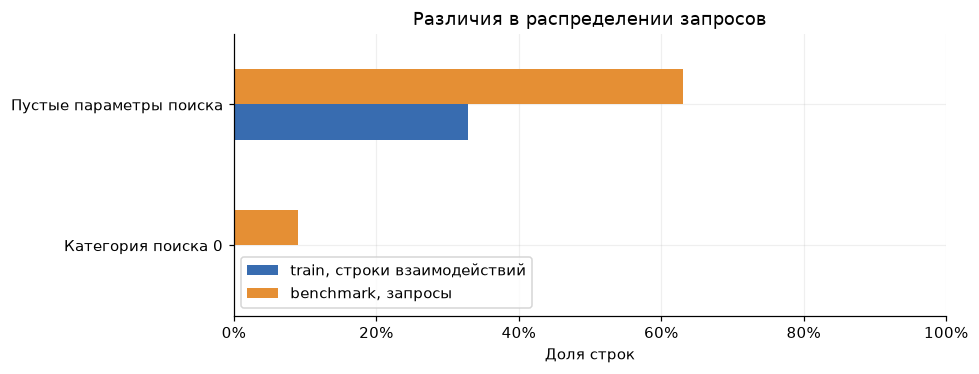

,query_id,search_query
663,aI8tBxMVKrhH4bEM,установка двери
2241,XfWOVaBnAE38Nwfk,установка двери


In [6]:
seen_text = qc.search_query.isin(set(tc.search_query))
seen_context = pd.MultiIndex.from_frame(qc).isin(pd.MultiIndex.from_frame(tc.drop_duplicates()))
overlap = pd.DataFrame([
    ['Benchmark items, встречавшиеся в train', len(train_ids & benchmark_ids), len(items)],
    ['Benchmark-запросы со знакомым нормализованным текстом', int(seen_text.sum()), len(queries)],
    ['Benchmark-запросы со знакомым полным контекстом', int(seen_context.sum()), len(queries)],
], columns=['Пересечение', 'Количество', 'Всего'])
overlap['Доля, %'] = 100 * overlap['Количество'] / overlap['Всего']
display(overlap.round(2))

shift = pd.DataFrame({
    'train, строки взаимодействий': [train.search_category.eq('0').mean(), train.search_infm_params_text.eq('').mean()],
    'benchmark, запросы': [queries.search_category.eq('0').mean(), queries.search_infm_params_text.eq('').mean()],
}, index=['Категория поиска 0', 'Пустые параметры поиска'])
ax = shift.plot.barh(color=COLORS)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set(xlabel='Доля строк', title='Различия в распределении запросов', xlim=(0, 1))
plt.tight_layout(); plt.show()
display(queries.loc[qc.search_query.duplicated(keep=False), ['query_id', 'search_query']])

**Вывод.** Только 9.59% benchmark-объявлений встречались в train. "Знакомый" нормализованный текст имеют 919 из 2452 запросов, полное совпадение контекста - 109. 

Категория 0 занимает 9.05% benchmark, но в train есть лишь 34 такие строки.

Два текста "установка`__`двери" / "установка`_`двери" нормализуются одинаково, но сохраняют разные query_id.

## 4. Категории и микрокатегории

Проверка соотствия категорий поиска и объявлений. 
Вероятность `P(item_category_id | search_category)` - доля данной категории объявлений среди
взаимодействий с выбранной категорией поиска.

item_category_id,10,112,114,19,27,28,40,81
search_category,,,,,,,,
0,0,0,34,0,0,0,0,0
10,0,0,2,0,0,0,0,0
114,1,2,497620,2,4,2,2,2
81,0,0,2,0,0,0,0,0


item_category_id,10,112,114,19,27,28,40,81
search_category,,,,,,,,
0,0.0000,0.0000,100.00000,0.0000,0.0000,0.0000,0.0000,0.0000
10,0.0000,0.0000,100.00000,0.0000,0.0000,0.0000,0.0000,0.0000
114,0.0002,0.0004,99.99699,0.0004,0.0008,0.0004,0.0004,0.0004
81,0.0000,0.0000,100.00000,0.0000,0.0000,0.0000,0.0000,0.0000


,train: уникальные объявления,benchmark: объявления
Категорий,8.0,47.0000
Микрокатегорий,212.0,752.0000
Доля категории 114,1.0,0.9901


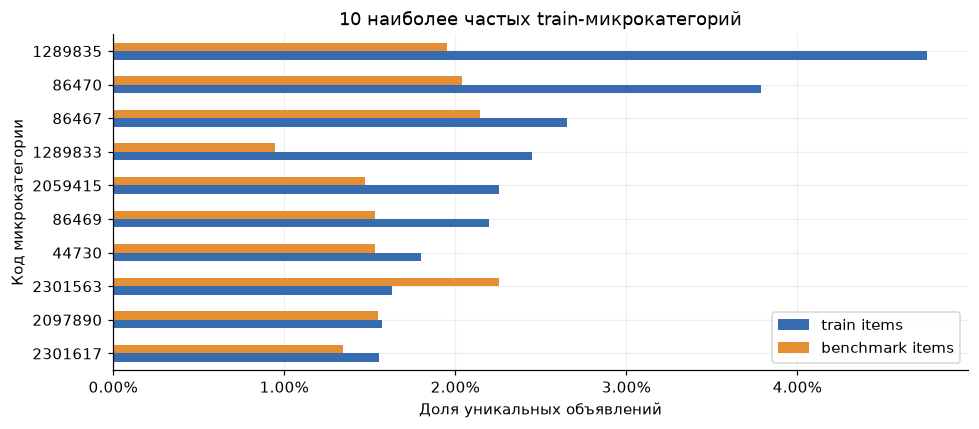

In [7]:
category_counts = pd.crosstab(train.search_category, train.item_category_id)
display(category_counts.rename_axis(index='search_category', columns='item_category_id'))
display(category_counts.div(category_counts.sum(axis=1), axis=0).mul(100).round(5))
display(pd.DataFrame({
    'train: уникальные объявления': [train_items.item_category_id.nunique(), train_items.item_microcat_id.nunique(), train_items.item_category_id.eq('114').mean()],
    'benchmark: объявления': [items.item_category_id.nunique(), items.item_microcat_id.nunique(), items.item_category_id.eq('114').mean()],
}, index=['Категорий', 'Микрокатегорий', 'Доля категории 114']).round(4))

micro = pd.DataFrame({
    'train items': train_items.item_microcat_id.value_counts(normalize=True),
    'benchmark items': items.item_microcat_id.value_counts(normalize=True),
}).fillna(0)
top_micro = micro.loc[micro['train items'].nlargest(10).index].sort_values('train items')
ax = top_micro.plot.barh(color=COLORS, figsize=(9, 4))
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set(xlabel='Доля уникальных объявлений', ylabel='Код микрокатегории', title='10 наиболее частых train-микрокатегорий')
plt.tight_layout(); plt.show()

**Вывод.** В train 8 категорий / 212 микрокатегорий, в benchmark — 47 / 752.
При этом 99% benchmark items относятся к категории 114. Все 34 train-взаимодействия
с search_category=0 относятся к item_category_id=114

## 5. География и delivery

Проверка взаимоотношения локации запроса и объявления.
Также проверяем сколько известных positives потеряется при полном исключении объявления из несоответвующей локации. Покрытие усредняется по контекстам как Recall, но не ограничивает число оставшихся объявлений до 50

,Взаимодействия,Совпадения,Доля совпадений
search_is_delivery_search,,,
0,497661,413570,0.831028
1,12,6,0.5


Delivery в benchmark: {0: 2452}


,"Среднее покрытие, %",Контекстов без positives,Контекстов с потерями
Совпадение локации,80.39873,67880,72012
Равенство категорий,99.98662,46,51
Только категория 114,99.99707,9,14


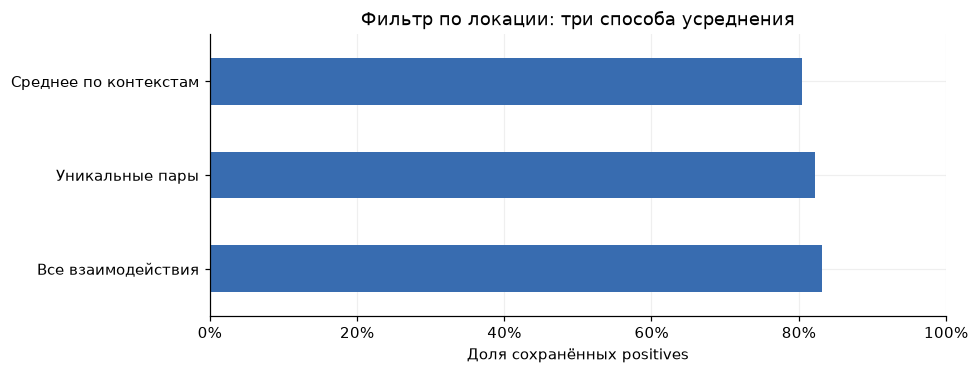

In [8]:
geo = train.assign(same_location=train.search_location_id.eq(train.item_location_id))
delivery = geo.groupby('search_is_delivery_search').same_location.agg(['size', 'sum', 'mean'])
display(delivery.rename(columns={'size': 'Взаимодействия', 'sum': 'Совпадения', 'mean': 'Доля совпадений'}))
print('Delivery в benchmark:', queries.search_is_delivery_search.value_counts().to_dict())

filter_masks = {
    'Совпадение локации': pairs.search_location_id.eq(pairs.item_location_id),
    'Равенство категорий': pairs.search_category.eq(pairs.item_category_id),
    'Только категория 114': pairs.item_category_id.eq('114'),
}
coverage = pd.DataFrame({name: mask.groupby(pairs.context_code).mean() for name, mask in filter_masks.items()})
display(pd.DataFrame({'Среднее покрытие, %': 100 * coverage.mean(),
                      'Контекстов без positives': coverage.eq(0).sum(),
                      'Контекстов с потерями': coverage.lt(1).sum()}).round(5))
location_rates = pd.Series({
    'Все взаимодействия': geo.same_location.mean(),
    'Уникальные пары': filter_masks['Совпадение локации'].mean(),
    'Среднее по контекстам': coverage['Совпадение локации'].mean(),
})
ax = location_rates.plot.barh(color=COLORS[0])
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set(xlim=(0, 1), xlabel='Доля сохранённых positives', title='Фильтр по локации: три способа усреднения')
plt.tight_layout(); plt.show()

**Вывод.** Локации совпадают у 83% взаимодействий / 82% уникальных пар.
Жесткий фильтр оставляет 80% positives по контекстам и полностью теряет
правильные ответы для 67 880 контекстов

## 6. Тексты, цены и рейтинги

Длинные параметры и описания могут ослаблять роль заголовка. Рассмотрим длины текстов и диапазоны числовых признаков. NULL-тексты при расчете длины считается пустой строкой

,Набор,Поле,Медиана,p95,Максимум
0,train,search_query,17.0,31.0,113.0
1,train,search_infm_params_text,28.0,97.0,1079.0
2,train,item_title_raw,34.0,50.0,100.0
3,train,item_infm_params_text,871.0,2965.0,11899.0
4,train,item_description_raw,920.0,3876.0,8494.0
5,benchmark_queries,search_query,22.0,39.0,70.0
6,benchmark_queries,search_infm_params_text,0.0,64.0,217.0
7,benchmark_items,item_title_raw,35.0,50.0,100.0
8,benchmark_items,item_infm_params_text,738.0,2475.0,19068.0
9,benchmark_items,item_description_raw,1054.0,4205.0,8494.0


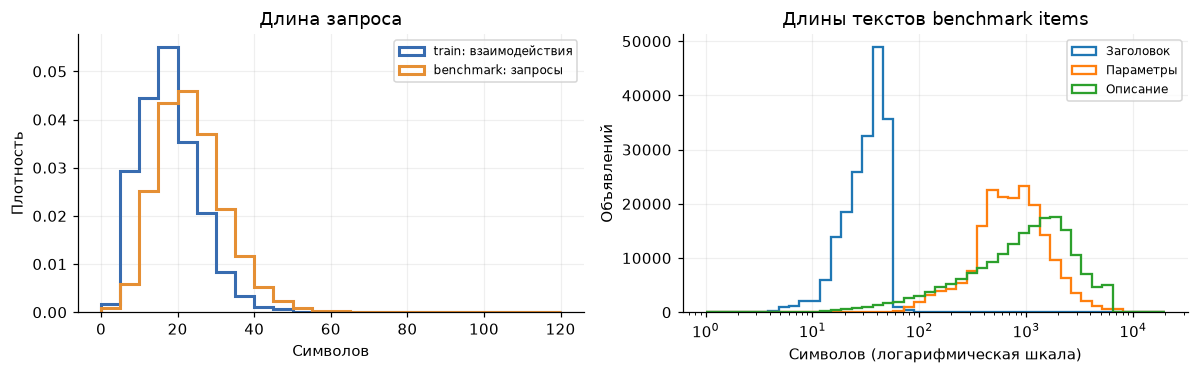

In [9]:
length_summary = pd.DataFrame([
    [name, field, *np.quantile(values, [.5, .95, 1])]
    for name, p in profiles.items() for field, values in p['lengths'].items()
], columns=['Набор', 'Поле', 'Медиана', 'p95', 'Максимум'])
display(length_summary.round(0))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for name, label, color in zip(['train', 'benchmark_queries'], ['train: взаимодействия', 'benchmark: запросы'], COLORS):
    axes[0].hist(profiles[name]['lengths']['search_query'], bins=np.arange(0, 121, 5), density=True,
                 histtype='step', linewidth=2, label=label, color=color)
for field, label in [('item_title_raw', 'Заголовок'), ('item_infm_params_text', 'Параметры'), ('item_description_raw', 'Описание')]:
    axes[1].hist(profiles['benchmark_items']['lengths'][field], bins=np.geomspace(1, 20000, 45),
                 histtype='step', linewidth=1.5, label=label)
axes[0].set(title='Длина запроса', xlabel='Символов', ylabel='Плотность')
axes[1].set(title='Длины текстов benchmark items', xlabel='Символов (логарифмическая шкала)', ylabel='Объявлений', xscale='log')
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

NULL   Нулей  Отрицательных  \
train items     item_price                     0.0  3257.0        23974.0   
                item_rating                23269.0  5649.0            0.0   
                item_rating_reviews_count  15694.0  7734.0            0.0   
benchmark items item_price                     0.0  1340.0        15248.0   
                item_rating                17631.0  3317.0            0.0   
                item_rating_reviews_count  11615.0  5064.0            0.0   

                                           Медиана       p99      Максимум  
train items     item_price                  1000.0   96000.0  1.000000e+12  
                item_rating                    5.0       5.0  5.000000e+00  
                item_rating_reviews_count     21.0     894.0  1.067800e+04  
benchmark items item_price                  1000.0  150000.0  7.777778e+11  
                item_rating                    5.0       5.0  5.000000e+00  
                item_rating_reviews_count     18.0     796.0  1.829100e+04

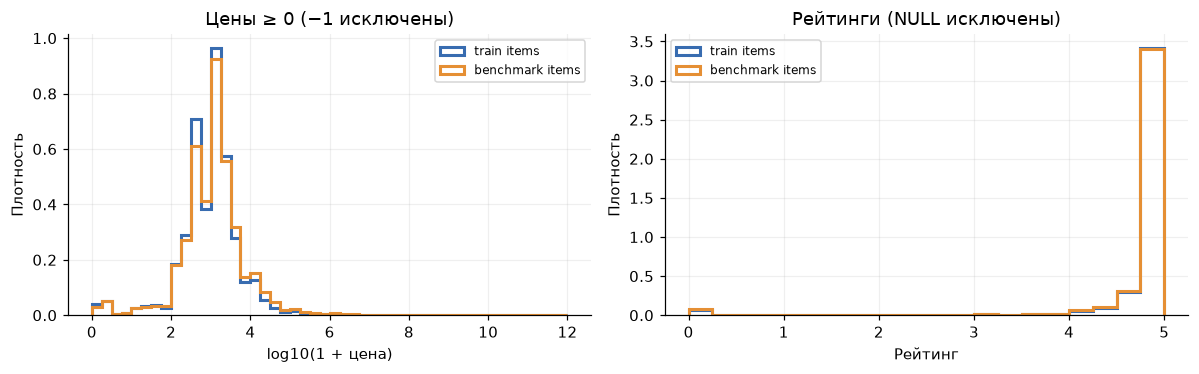

In [10]:
numeric = {}
for name, frame in [('train items', train_items), ('benchmark items', items)]:
    for field in ['item_price', 'item_rating', 'item_rating_reviews_count']:
        values = frame[field].astype('Float64')
        numeric[(name, field)] = {'NULL': int(values.isna().sum()), 'Нулей': int(values.eq(0).sum()),
            'Отрицательных': int(values.lt(0).sum()), 'Медиана': values.median(),
            'p99': values.quantile(.99), 'Максимум': values.max()}
display(pd.DataFrame(numeric).T)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for (name, frame), color in zip([('train items', train_items), ('benchmark items', items)], COLORS):
    price = frame.item_price.astype('float64')
    axes[0].hist(np.log10(1 + price[price.ge(0)]), bins=np.linspace(0, 12, 49),
                 density=True, histtype='step', linewidth=2, color=color, label=name)
    axes[1].hist(frame.item_rating.dropna().astype('float64'), bins=np.linspace(0, 5, 21),
                 density=True, histtype='step', linewidth=2, color=color, label=name)
axes[0].set(title='Цены ≥ 0 (−1 исключены)', xlabel='log10(1 + цена)', ylabel='Плотность')
axes[1].set(title='Рейтинги (NULL исключены)', xlabel='Рейтинг', ylabel='Плотность')
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Вывод.** 
Медианы train-текстов: заголовок 34, параметры 871, описание 920 символов.

Цена -1 есть у 23 974 train items и 15 248 benchmark items

При медианной цене 1000 встречаются выбросы до сотен миллиардов

Медианный рейтинг - 5

## 7. Фиксируем validation split

split: около 15% **нормализованных текстов запросов** целиком идут
в validation, со всеми локациями и фильтрами. Конкретный выбор задаёт SHA-256 с неизменным
префиксом `avito-validation-v1:42:`

In [13]:
def in_validation(text):
    digest = hashlib.sha256(('avito-validation-v1:42:' + text).encode()).digest()
    return int.from_bytes(digest[:8], 'big') < int(.15 * 2**64)

is_val = tc.search_query.map({text: in_validation(text) for text in tc.search_query.unique()})
fit_contexts = set(train.loc[~is_val, 'context_code'])
val_contexts = set(train.loc[is_val, 'context_code'])
val_pairs = pairs[pairs.context_code.isin(val_contexts)]
val_positive_counts = val_pairs.groupby('context_code').size()
split_table = pd.DataFrame({
    name: {'Взаимодействия': int(mask.sum()), 'Тексты': tc.loc[mask, 'search_query'].nunique(),
           'Контексты': train.loc[mask, 'context_code'].nunique()}
    for name, mask in [('fit', ~is_val), ('validation', is_val)]
})
display(split_table)
display(pd.Series({
    'Validation: уникальные положительные пары': len(val_pairs),
    'Validation: уникальные положительные объявления': val_pairs.item_id.nunique(),
    'Максимум positives на validation-контекст': val_positive_counts.max(),
    'Доля validation-пар с item_id из benchmark': val_pairs.item_id.isin(benchmark_ids).mean(),
    'Размер локального каталога (все train items)': len(train_ids),
}, name='Значение').to_frame())

assert not set(tc.loc[is_val, 'search_query']) & set(tc.loc[~is_val, 'search_query'])
assert not fit_contexts & val_contexts
assert set(val_pairs.item_id) <= train_ids
assert split_table.loc['Взаимодействия'].sum() == len(train)
assert split_table.loc['Контексты'].sum() == len(positives)
assert positives.sum() == len(pairs)
assert queries.query_id.is_unique and items.item_id.is_unique
print('Проверки пройдены: контексты и тексты не пересекаются, все positives доступны в каталоге.')

,fit,validation
Взаимодействия,430780,66893
Тексты,62666,11040
Контексты,303490,50751


,Значение
Validation: уникальные положительные пары,63502.000000
Validation: уникальные положительные объявления,58308.000000
Максимум positives на validation-контекст,40.000000
Доля validation-пар с item_id из benchmark,0.062707
Размер локального каталога (все train items),344825.000000


Проверки пройдены: контексты и тексты не пересекаются, все positives доступны в каталоге.


**Протокол.** Получили 50 751 validation-контекст, 63 502 уникальные пары и 58 308 положительных
объявлений

Считаем среднее по контекстам: `Recall@K = |topK ∩ positives| / |positives|`, K = 10, 20, 50